In [1]:
import pandas as pd
df=pd.read_csv("Datasets/all_athlete_games.csv", low_memory=False)

In [2]:
age=df['Age']
print(df['Age'].count())
age_with_outlier=pd.concat([age,pd.Series([200])])

print("Mean before:",age.mean())
print("Mean after:",age_with_outlier.mean())

print("Median before:",age.median())
print("Median after:",age_with_outlier.median())

287876
Mean before: 25.66124303519571
Mean after: 25.661848636744164
Median before: 25.0
Median after: 25.0


In [3]:
age=df['Age'].iloc[16:31]
print(df['Age'].count())
age_with_outlier=pd.concat([age,pd.Series([200])])

print("Mean before:",age.mean())
print("Mean after:",age_with_outlier.mean())

print("Median before:",age.median())
print("Median after:",age_with_outlier.median())

287876
Mean before: 23.8
Mean after: 34.8125
Median before: 25.0
Median after: 25.0


In [4]:
#Central tendency - Mean vs Median

#Mean= add up every value, devide by how many are there.
#Every Ssingle value pulls on the result

#Median= sort all the values, take the exact middle one.
#Only position matters, not how far away extreme values are

pd.set_option('display.max_rows',None)
df.groupby('Sport')['Age'].agg(['mean','median'])

,mean,median
Sport,,
3x3 Basketball,28.437500,28.0
Aeronautics,26.000000,26.0
Alpine Skiing,23.205462,23.0
Alpinism,38.812500,38.0
Archery,27.789411,26.0
Art Competitions,45.901009,45.0
Artistic Gymnastics,23.035815,23.0
Artistic Swimming,23.782258,23.0
Athletics,25.258004,25.0


In [5]:
#Dispersion-Range,Variance,Standard Deviation

#Central tendency tells you where the middle is
#Dispersion tells you how spread out the values are around that middle

#Two columns can have the same excat mean but looks completely different
#If one is tightly clustered and the other is scattered wide

#Range
age.max()-age.min()
#This is just the distance b/w the highest and the lowest value
#Only based on two data points, so one extreme outlier on either end determines the range, regardless of what the other 283000 values looks like.

np.float64(5.0)

In [6]:
#Variance - average squared distance from the mean
age=df['Age']
age.var()

#How it's actually calculated, conceptually:
# 1. Take every value's distance from the mean (value - mean)
# 2. Square each distance (so negative and positive distances don't cancel out, and bigger distances count disproportionately more)
# 3. Average all those squared distances

#Variance does not give any value or esult on its own
#It is only a step of calculation to get standard deviation


np.float64(40.0490227383145)

In [7]:
#Standard Deviation - through variance
age.std()
#Standard Deviation is just square root of variance
print(f"Mean age:{age.mean():.1f}, Std:{age.std():.1f}")

#Small std means values cluster tightly around mean
#Large std means values are spread widely

#Sports with a high std have a wide mix of ages competing
#Sports with a low std have athletes clustered tightly around similar age.


Mean age:25.7, Std:6.3


In [8]:
df.groupby('Sport')['Age'].agg(['mean','std'])

,mean,std
Sport,,
3x3 Basketball,28.437500,5.182005
Aeronautics,26.000000,NaN
Alpine Skiing,23.205462,3.987876
Alpinism,38.812500,9.703736
Archery,27.789411,8.653183
Art Competitions,45.901009,12.717193
Artistic Gymnastics,23.035815,4.167330
Artistic Swimming,23.782258,4.037548
Athletics,25.258004,4.415824


In [9]:
#Outlier Logic - IQR AND Whiskers

#This is a rule for deciding how extreme does a value have to be before calling it an outlier

#It is built entirely from the middle 50% of the data, which makes it resistant to being thrown off by the outliers it is trying to detect

#step1 --> Q1 to Q3 (quartiles)
#[Group 1]|[Group 2]|[Group 13]|[Group 4]
#         Q1        Q2         Q3 

q1=age.quantile(0.25) #25th percentile of the data
q3=age.quantile(0.75) #75th percentile of the data

print(q1,q3)
#quantile(0.25) means find the value at 25% of the way through point once everything is stored 
#Same for 75% point

#Here this means
#25% of all athletes are age 22 or younger
#75% of all athletes are age 28 or younger


22.0 28.0


In [10]:
#IQR --> Inter quartile range

print(q3-q1)
iqr=(q3-q1)

#So q1 and q3 tells you the middle section 50% of the athletes falls somewhere between age of 22 and 28

#IQR is just the width of that middle 50% block
#how many years wide is the chunk of ages
#28-22 = 6 years wide

#Which tells you how spread out the part of your data is ignoring the extreme oldest quarter and extreme youngest quarter

6.0


In [11]:
#Whiskers (where outliers start)
lower_whisker=q1-1.5*iqr
upper_whisker=q3+1.5*iqr

print(lower_whisker,upper_whisker)

13.0 37.0


12922
191       10.0
207       39.0
208       39.0
209       39.0
210       39.0
357       40.0
383       42.0
394       57.0
408       40.0
453       38.0
454       38.0
455       38.0
484       45.0
493       46.0
499       48.0
516       42.0
517       42.0
518       42.0
519       42.0
520       42.0
523       45.0
524       45.0
585       40.0
611       44.0
621       43.0
657       52.0
667       40.0
705       38.0
724       42.0
743       40.0
744       40.0
745       40.0
748       39.0
750       56.0
764       41.0
777       40.0
778       40.0
782       52.0
791       43.0
793       44.0
800       45.0
802       49.0
813       53.0
814       53.0
815       53.0
816       38.0
819       41.0
890       56.0
904       49.0
905       49.0
906       49.0
921       69.0
954       40.0
955       40.0
969       38.0
970       42.0
971       44.0
1052      42.0
1054      43.0
1055      43.0
1101      50.0
1102      47.0
1103      47.0
1104      47.0
1129      38.0
1130      39.0
1131

<Axes: >

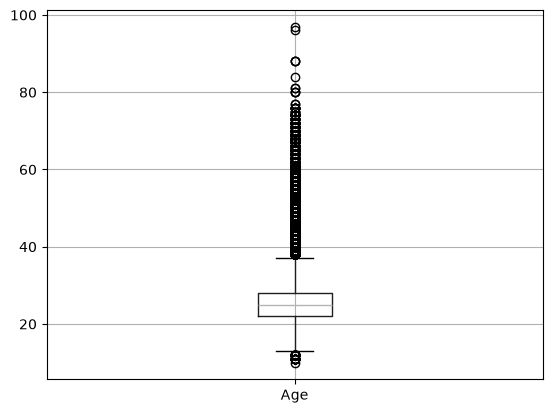

In [12]:
#Flagging the outliers
outliers=age[(age<lower_whisker)|(age>upper_whisker)]
print(len(outliers))
print(outliers)
print(outliers.min(),outliers.max())
outliers.head
df.boxplot(column='Age') #Visualizing the boxplot

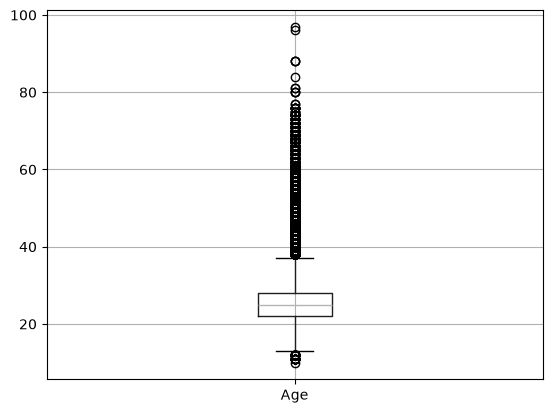

In [13]:
import matplotlib.pyplot as plt
df.boxplot(column='Age') #Visualizing the boxplot
plt.show()

| Term | Plain-English meaning |
|---|---|
| Q1 | The age below which the youngest 25% of athletes fall |
| Q3 | The age below which the oldest 75% of athletes fall (i.e. the oldest 25% are above this) |
| IQR | How wide the "typical middle half" of ages is (Q3 - Q1) |
| Whiskers | A buffer zone stretched 1.5x that typical width beyond each edge |
| Outlier | Any value falling outside that buffer zone entirely |